# 《基于 BiLSTM-XGBoost 时空级联架构的多污染物协同预测模型》

**原始数据描述：**

"data.csv"中给出了北京房山良乡地区2026年1月1日-3月31日逐小时的空气质量监测数据，包含：

* PM2.5 (μg/m³)
* PM10 (μg/m³)
* O₃ (μg/m³)
* NO₂ (μg/m³)
* SO₂ (μg/m³)
* CO (mg/m³)
* temperature（℃）（同时段温度）
* humidity（%）（相对湿度）

**基于原始数据创建的特征：**

* **时间周期特征：**
    * 小时 (Hour, 0-23) 及其正余弦连续性编码 (Hour_sin, Hour_cos)
    * 星期几 (Day of Week, 0-6)
    * 是否周末 (Is_Weekend, 0/1)
    * 月份 (Month, 1-3)
    * 是否供暖 (Is_Heating, 0/1)
* **气象及其衍生特征：**
    * 温湿度交互特征 (Temp_Humid_Interact) 
    * 过去3小时的气象移动平均 (temp_rolling3_mean, humid_rolling3_mean)
    * 过去6小时的最大温差 (temp_rolling6_diff)
    * 温度与湿度滞后 (temperature_lag{i}, humidity_lag{i}) (i = 1, 2, 3)
* **污染物历史特征（用于预测未来 t+1 时刻的浓度）：**
    * 当前时刻 $t$ 的真实浓度 (PM2.5, PM10, O₃, NO₂, SO₂, CO)
    * 过去 $t-1, t-2, t-3$ 时刻的污染物滞后浓度 (PM2.5_lag{i}, O₃_lag{i} 等)

**预测目标设定：**
基于时间序列预测的严谨性，本文采用 $Shift(-1)$ 策略，将目标变量设定为**未来下一小时（$t+1$ 时刻）**的六种污染物浓度。模型利用 $t$ 时刻及以前的气象与污染状态，推断未来的空气质量演化。

## 1.基础库导入 & 全局设置

In [3]:
# 基础库导入
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt

# 忽略警告信息，保持输出界面整洁
warnings.filterwarnings('ignore')

# 设置随机种子，保证每次运行的结果一致
SEED = 43
random.seed(SEED)
np.random.seed(SEED)

# 魔法命令，确保图表在Notebook中直接显示
%matplotlib inline

# Matplotlib 全局参数设置
plt.style.use('bmh')
plt.rcParams['figure.figsize'] = [16, 8]
plt.rcParams['font.size'] = 18

# Pandas 全局显示设置 (显示所有列和行，不换行)
pd.options.display.max_columns = None
pd.options.display.max_rows = None
pd.set_option('display.expand_frame_repr', False)

sns.set()

## 2.加载数据集

In [4]:
try:
    df = pd.read_csv('data.csv')
    print("数据加载成功！")
except FileNotFoundError:
    print("错误：未找到数据文件，请检查文件路径是否正确！")

# 预览前5行数据

df.head()

数据加载成功！


,datetime,PM2.5,PM10,O3,NO2,SO2,CO,temperature,humidity
0,2026/1/1 0:00,38,59,14,35,3,0.9,-5.8,47
1,2026/1/1 1:00,41,63,12,37,3,0.9,-6.2,46
2,2026/1/1 2:00,44,66,10,40,3,1.0,-6.5,45
3,2026/1/1 3:00,46,69,9,42,3,1.0,-6.8,44
4,2026/1/1 4:00,48,71,8,43,3,1.1,-7.0,43


## 3. 数据信息查看

In [5]:
df.dtypes

datetime           str
PM2.5            int64
PM10             int64
O3               int64
NO2              int64
SO2              int64
CO             float64
temperature    float64
humidity         int64
dtype: object

In [6]:
# 数据集大小

df.shape

(2161, 9)

In [7]:
# 数据集概览

df.describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,2161.0,60.503933,16.003012,17.0,48.0,61.0,73.0,101.0
PM10,2161.0,89.465525,21.812922,31.0,72.0,89.0,106.0,151.0
O3,2161.0,43.954651,19.034637,5.0,31.0,41.0,61.0,87.0
NO2,2161.0,52.823693,15.140298,13.0,41.0,53.0,67.0,76.0
SO2,2161.0,2.698288,0.606784,2.0,2.0,3.0,3.0,4.0
CO,2161.0,0.736465,0.275485,0.3,0.5,0.8,0.9,1.2
temperature,2161.0,7.096391,6.291719,-7.3,2.4,7.6,11.9,20.1
humidity,2161.0,78.427117,14.929538,39.0,65.0,84.0,91.0,100.0


## 4.数据清洗

### 4.1 时间格式转换与索引设置

* 目的：让程序认识“时间”，方便后续提取时间特征和做时序分析。
* 操作：将 datetime 列转换为 Pandas 的 datetime 对象，并将其设置为数据的 Index。

In [8]:
# 转换时间格式并设为索引
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
    df.set_index('datetime', inplace=True)

### 4.2 缺失值处理

* 目的：填补传感器故障或传输丢失导致的空缺数据

In [9]:
# 检查是否存在缺失值

df.isnull().sum().sum()

np.int64(0)

结果显示无缺失值，故这里并不需要对缺失值进行处理。

### 4.3 异常值检测与处理
* 目的：排除极端错误数据（如仪器校准错误导致的负浓度，或极高的离谱值）。
* 操作：
    * 常识判断：所有污染物的浓度不能小于0。相对湿度必须在 0-100% 之间。如果有，直接置为 NaN，再用插值填补。


In [10]:
# 1. 剔除违反物理常识的异常值
for col in ['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO', 'humidity']:
    df.loc[df[col] < 0, col] = np.nan # 浓度和湿度不能为负
df.loc[df['humidity'] > 100, 'humidity'] = np.nan # 湿度不能大于100

# 2. 时间插值填补刚才挖空的异常值，保证时序连续
df = df.interpolate(method='time')

## 5.特征工程

### 5.1 时间维度的特征提取
空气污染具有极强的周期性。这些特征可以作为“人类活动（交通、工厂排放）”和“太阳辐射”的替代变量。

* 小时 (Hour, 0-23)：极度重要！能捕捉早晚高峰（NO2, CO激增）和午后高温（O3在紫外线和高温下由NOx和VOCs光化学反应生成，通常下午达到峰值）。
* 星期几 (Day of Week, 0-6) / 是否周末 (Is_Weekend)：捕捉工作日（通勤、施工量大）和周末的排放差异。
* 月份 (Month, 1-3)：注意，北京通常在3月中旬停止集中供暖。 
* 是否供暖 (Is_Heating_Season)：捕捉供暖季节的影响，这对于解释PM2.5和SO2可能存在帮助。

In [11]:
# 时间列是索引（DatetimeIndex）
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df['Month'] = df.index.month

# 供暖季特征 (假设3月15日停暖)
df['Is_Heating'] = df.index.map(lambda x: 1 if (x.month < 3) or (x.month == 3 and x.day <= 15) else 0)

### 5.2 滞后特征
当前的空气质量不仅取决于现在的温湿度，更取决于几个小时前的状态。同时，空气污染是不易散去的，前一小时的浓度极大程度上决定了这一小时的浓度。

* 气象滞后：构建温度和湿度的滞后 1小时、2小时、3小时、甚至 6小时的特征。
* 自回归滞后 (Auto-regressive Lags)：构建6种污染物自身前 1小时、2小时的浓度作为特征。

In [12]:
# 构造滞后特征 (假设往回看3个小时)
lag_hours = 3
target_cols = ['temperature', 'humidity', 'PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']

for col in target_cols:
    for i in range(1, lag_hours + 1):
        df[f'{col}_lag{i}'] = df[col].shift(i)

### 5.3 滑动窗口
有时候单点的滞后数据会有波动，过去一段时间的平均状态更能反映整体气象条件。
* 气象的移动平均：过去3小时、6小时的平均温度和湿度。
* 温差特征：当前温度减去过去6小时最低温度（可以反映逆温层的破坏情况，逆温层是导致重污染的元凶）。

In [13]:
# 过去3小时的平均温度和湿度
df['temp_rolling3_mean'] = df['temperature'].rolling(window=3).mean()
df['humid_rolling3_mean'] = df['humidity'].rolling(window=3).mean()

# 过去6小时的最大温差 (辅助判断大气稳定性)
df['temp_rolling6_diff'] = df['temperature'].rolling(window=6).max() - df['temperature'].rolling(window=6).min()

### 5.4 激活时间特征

在处理时间变量时，传统的线性编码（如 0-23 时）无法体现时间的连续周期性（即 23 点与次日 0 点在物理上是相邻的）。因此，本文引入**正余弦周期性编码 (Sine/Cosine Encoding)**，将一维的时间特征映射到二维连续的单位圆空间上。其数学变换公式如下： 

$$ Time_{sin} = \sin\left(\frac{2\pi \cdot t}{T}\right), \quad Time_{cos} = \cos\left(\frac{2\pi \cdot t}{T}\right) $$

其中，$t$ 为当前时刻，$T$ 为时间周期（如小时特征 $T=24$）。此外，为探究气象的联合驱动机制，本文构建了温湿度交互特征   $Temp \times Humid$，以增强模型对复杂天气（如高温高湿）的非线性捕捉能力。

In [14]:
# --- 进阶特征构造  ---
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
df['Temp_Humid_Interact'] = df['temperature'] * df['humidity']

# 删除因构造滞后特征产生的缺失值
df = df.dropna()

# 【关键】：在 shift 之前，克隆一份纯净的原始数据，专门留给 第7部分画图 和 第9部分提取真实温湿度用
df_raw = df.copy() 

## 6.数据预处理

### 6.1构造真正的预测目标 (预测未来下一小时 t+1)

In [15]:
pollutants = ['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']

for col in pollutants:
    df[f'{col}_target'] = df[col].shift(-1)

df = df.dropna()

### 6.2 数据集的划分

In [16]:
train_df = df[:'2026-03-15']
test_df = df['2026-03-16':]

target_cols = [f'{col}_target' for col in pollutants]
feature_cols = [col for col in df.columns if col not in target_cols]

X_train = train_df[feature_cols].copy()
Y_train = train_df[target_cols].copy()
X_test = test_df[feature_cols].copy()
Y_test = test_df[target_cols].copy()

from sklearn.preprocessing import StandardScaler
# 找出需要标准化的连续变量 (排除时间编码、分类变量)
cols_to_scale = [col for col in feature_cols if col not in ['Hour', 'Hour_sin', 'Hour_cos', 'DayOfWeek', 'Is_Weekend', 'Month', 'Is_Heating']]

scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("数据集划分与特征工程重构完成！")

数据集划分与特征工程重构完成！


## 7.问题一

> **题目要求：** 分析单一污染物浓度与时间、温度、湿度之间的关系，并给出合理的解释。

### 7.1 污染物与【时间】的关系分析

#### 7.1.1 日变化规律 (24小时趋势)
直观反映人类活动（如早晚高峰）和自然规律（如日照）。

为了消除不同污染物浓度量纲和数量级的差异，使它们在统一尺度上进行比较和可视化，本研究采用了 **Z-score 标准化**（也称标准差标准化）方法对原始数据进行了预处理。

Z-score 标准化是一种常见的数据归一化技术，其核心思想是将原始数据转换为均值为 0、标准差为 1 的标准正态分布数据。对于任意一个数据点 $x$，其标准化后的值 $z$ 通过以下公式计算：

$$
z = \frac{x - \mu}{\sigma}
$$

其中：
- $x$ 是原始数据值；
- $\mu$ 是该污染物所有观测值的平均值；
- $\sigma$ 是该污染物的标准差。

通过该变换，不同污染物的浓度值被映射到同一尺度，从而可以直观地比较它们在24小时内的变化趋势。例如，标准化后的正值表示该时刻的浓度高于全天平均水平，负值则表示低于平均水平。这种处理方式不仅有助于消除量纲影响，还能更清晰地揭示污染物浓度的相对波动规律，为后续分析污染物与时间、温度、湿度等因素的相关性提供基础。

在本研究中，我们对六种主要污染物（PM2.5、PM10、O3、NO2、SO2、CO）分别进行了Z-score标准化，并基于标准化后的数据绘制了24小时平均浓度趋势图，以更直观地展示其日变化规律。

In [17]:
# ======== 中文字体设置（防止图表里的中文变成方块） ========
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 需要分析的六种污染物
pollutants = ['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']

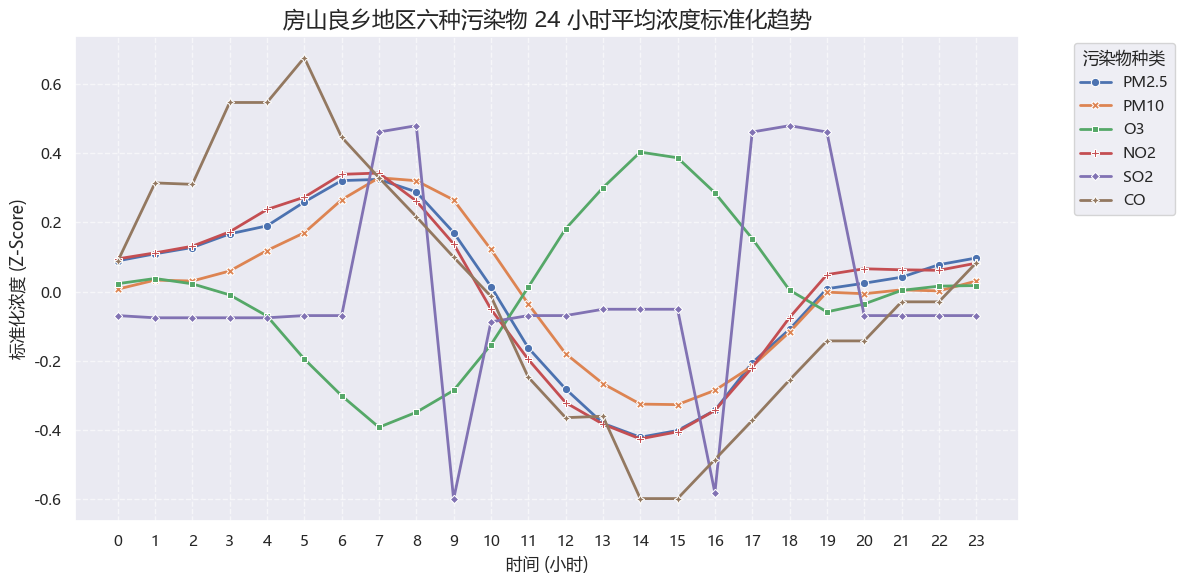

In [18]:
from sklearn.preprocessing import StandardScaler

# 1. 我们临时拷贝一份原始数据，专门用来画这张对比图
plot_df = df_raw.copy()

# 2. 仅针对画图，对六种污染物进行 Z-score 标准化
temp_scaler = StandardScaler()
pollutants = ['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']
plot_df[pollutants] = temp_scaler.fit_transform(plot_df[pollutants])

# 3. 按小时分组求均值 (使用我们临时标准化的 plot_df)
hourly_mean_norm = plot_df.groupby('Hour')[pollutants].mean()

# 4. 画折线图
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_mean_norm, dashes=False, markers=True, linewidth=2)
plt.title('房山良乡地区六种污染物 24 小时平均浓度标准化趋势', fontsize=16)
plt.xlabel('时间 (小时)', fontsize=12)
plt.ylabel('标准化浓度 (Z-Score)', fontsize=12)
plt.xticks(range(0, 24)) # X轴显示 0-23
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='污染物种类', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

图表现象为PM2.5、PM10、NO2、CO、SO2呈现明显的双峰双谷形态，峰值出现在上午8至10时和傍晚19至21时，午后浓度明显下降。O3走势完全相反，午后14至16时出现明显单峰，夜间浓度处于最低谷。
成因解释如下：首先，上午8至10时和傍晚19至21时与交通高峰时段吻合，机动车尾气集中排放NO2、CO和一次颗粒物。1至3月北京清晨气温低，容易形成贴地逆温层，垂直扩散受阻，污染物在近地面累积，出现峰值。其次，午后气温升高，大气边界层抬升，垂直湍流增强，一次污染物迅速向高空扩散稀释，浓度降至全日低谷。再者，臭氧并非直接排放，而是在太阳紫外辐射下由NOx和VOCs光化学反应生成。午后太阳辐射最强、气温最高，光化学反应速率达到顶峰，O3浓度最高。夜间大气氧化性减弱，且机动车排放的NO与O3发生反应生成NO2和O2，使O3被快速消耗，浓度跌至谷底。


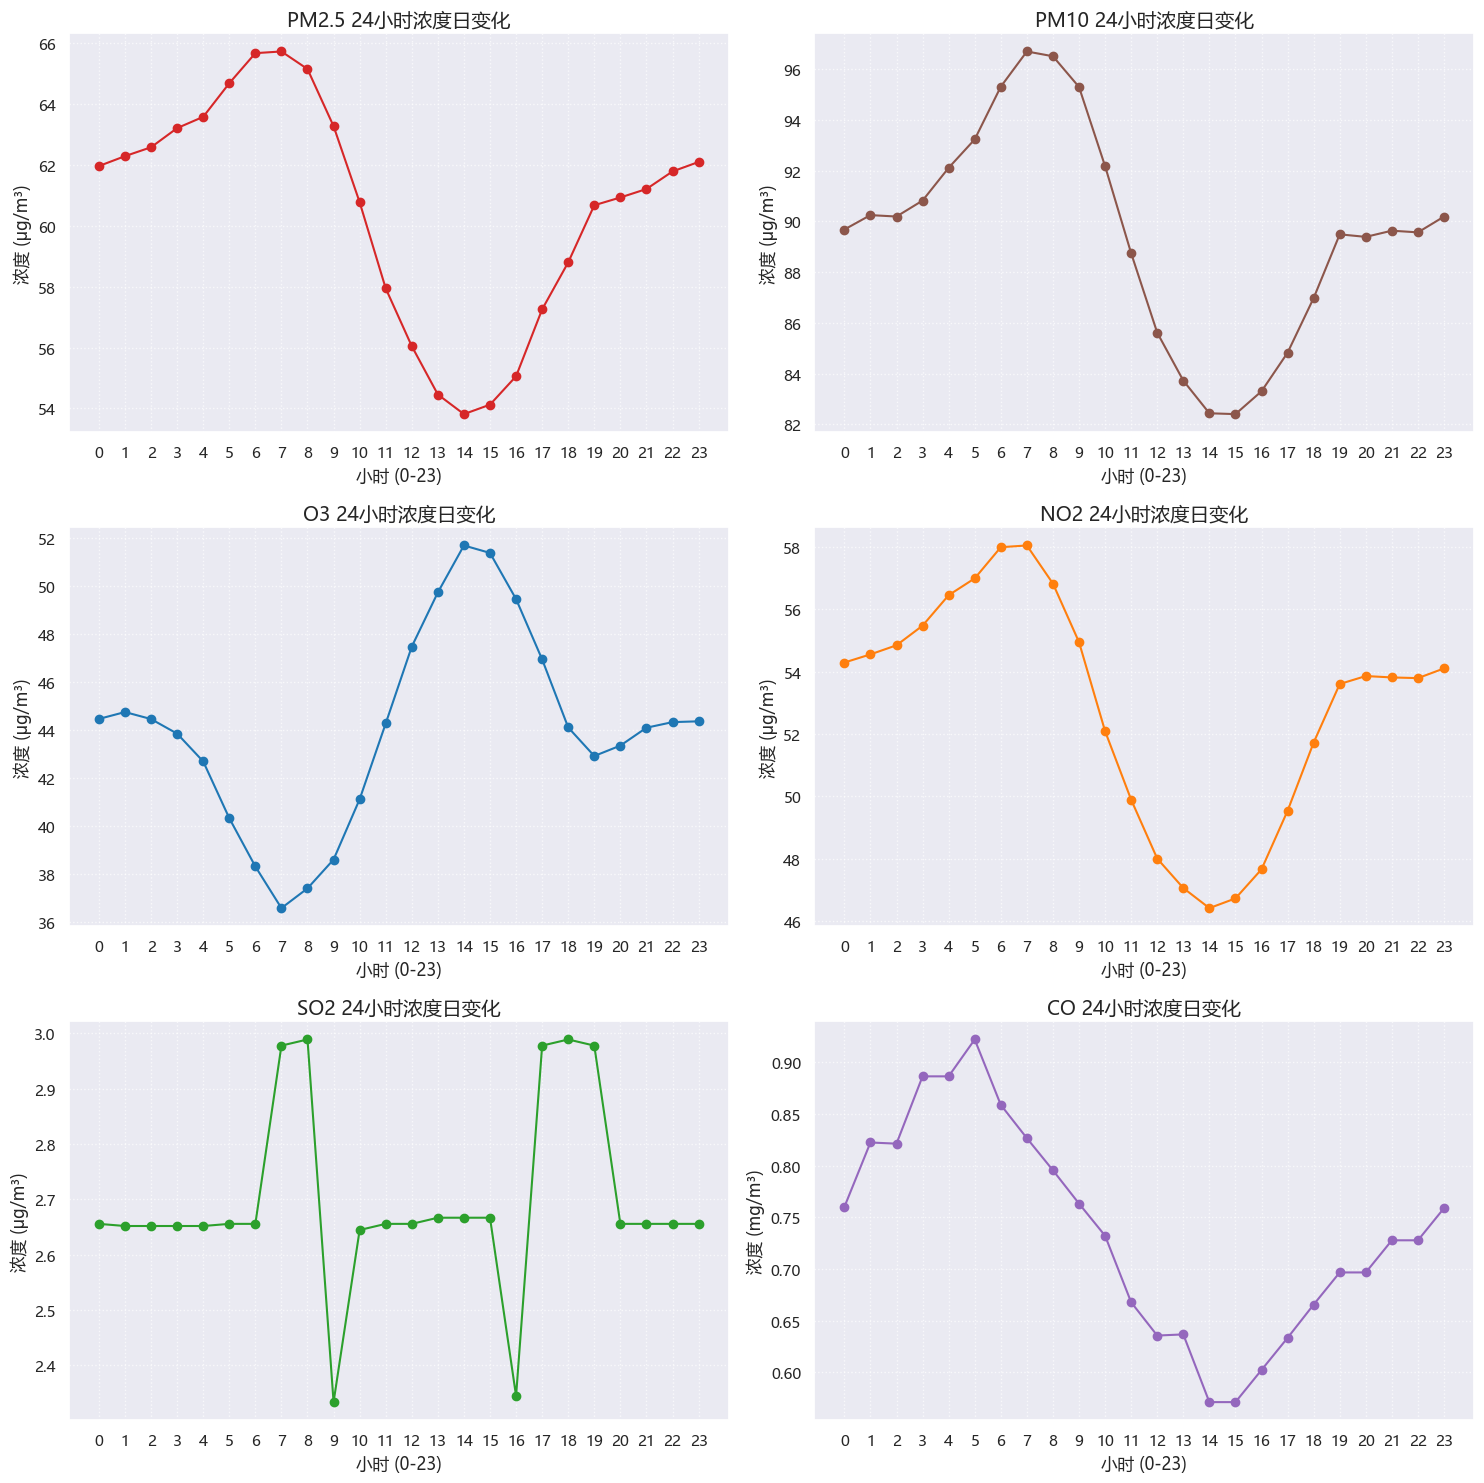

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()
hourly_mean_raw = df_raw.groupby('Hour')[pollutants].mean()

colors = ['#d62728', '#8c564b', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

for i, col in enumerate(pollutants):
    axes[i].plot(hourly_mean_raw.index, hourly_mean_raw[col], marker='o', color=colors[i])
    axes[i].set_title(f'{col} 24小时浓度日变化', fontsize=14)
    axes[i].set_xlabel('小时 (0-23)')
    
    # 根据污染物不同设置不同的纵坐标单位
    if col == 'CO':
        axes[i].set_ylabel('浓度 (mg/m³)')
    else:
        axes[i].set_ylabel('浓度 (μg/m³)')
        
    axes[i].set_xticks(range(0, 24))
    axes[i].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

这里的看图解析就交给你了哈哈哈哈哈 SO2有点奇怪


#### 7.1.2 周变化与月度变化规律 （这个稍微提一下就好了）（表示我们考虑到了，但是规律并不突出）

宏观时间能反映人类工作休息规律以及季节气候的更替。

周末效应对比

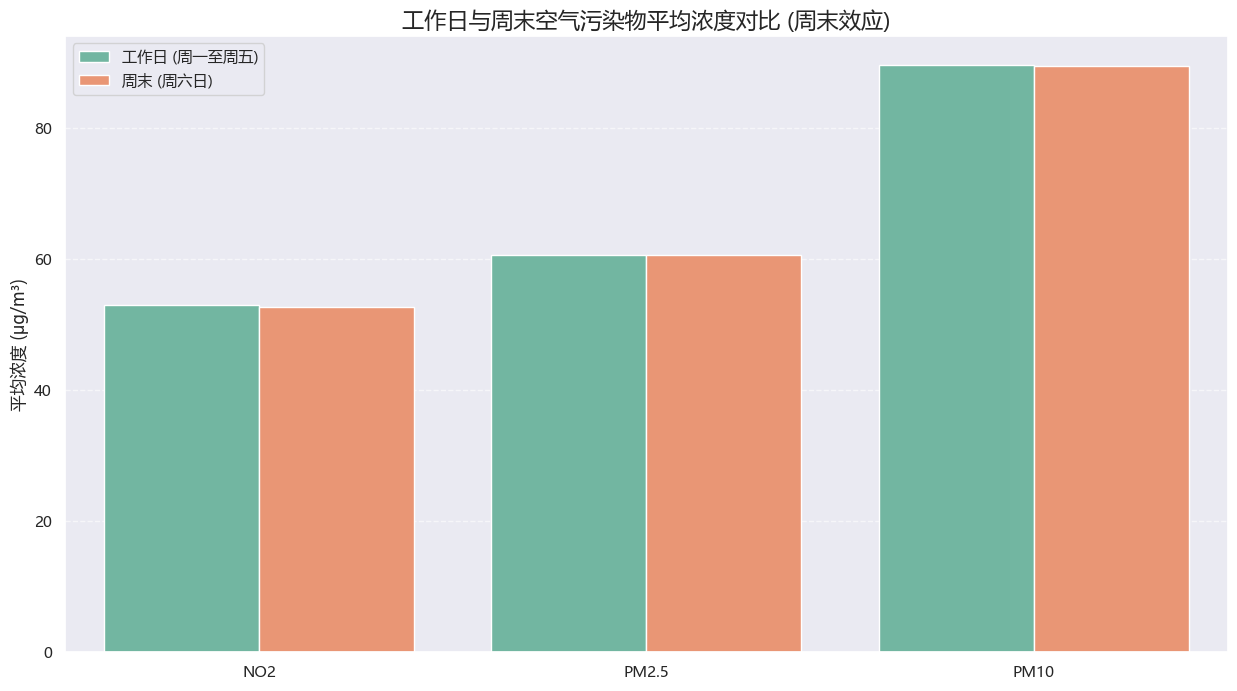

In [20]:
plt.figure(figsize=(15, 8))
# 0代表工作日，1代表周末。我们看NO2和PM2.5的均值对比
weekend_compare = df_raw.groupby('Is_Weekend')[['NO2', 'PM2.5', 'PM10']].mean().reset_index()

# 转换数据格式以适应柱状图绘制
weekend_melted = weekend_compare.melt(id_vars='Is_Weekend', var_name='污染物', value_name='平均浓度')
weekend_melted['Is_Weekend'] = weekend_melted['Is_Weekend'].map({0: '工作日 (周一至周五)', 1: '周末 (周六日)'})

sns.barplot(data=weekend_melted, x='污染物', y='平均浓度', hue='Is_Weekend', palette='Set2')
plt.title('工作日与周末空气污染物平均浓度对比 (周末效应)', fontsize=16)
plt.ylabel('平均浓度 (μg/m³)', fontsize=12)
plt.xlabel('')
plt.legend(title='')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

月份更替（供暖季与非供暖季）

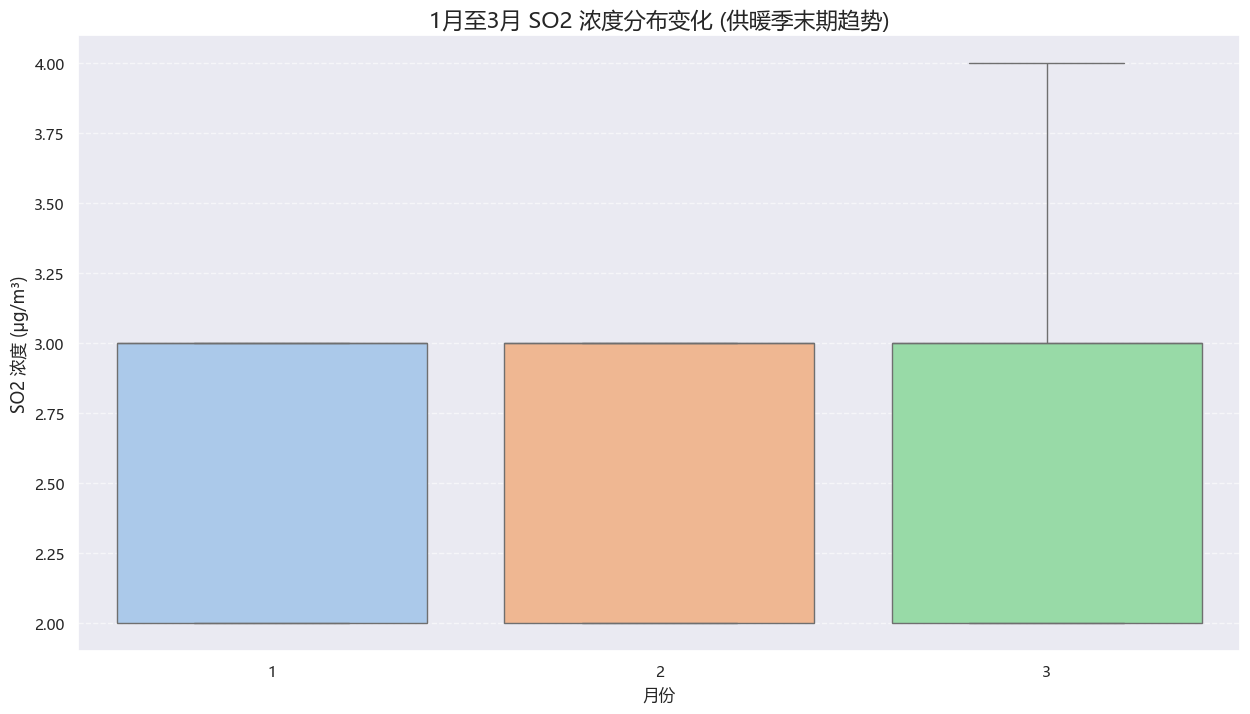

In [21]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_raw, x='Month', y='SO2', palette='pastel')
plt.title('1月至3月 SO2 浓度分布变化 (供暖季末期趋势)', fontsize=16)
plt.xlabel('月份', fontsize=12)
plt.ylabel('SO2 浓度 (μg/m³)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

这两张图好像讲不出来什么东西，我觉得这里可以跳过，或者一笔带过就行。

以下是AI建议我们写进去的亮点，但是我觉得其实大可不必哈哈哈哈哈哈哈

1.  **为什么没有“周末效应”？**
    *   *地理位置因素*：房山良乡是典型的大学城和城郊居住区，不像北京CBD或工业区有极强的“工作日通勤/生产”与“周末休息”的潮汐反差。这里的日常交通和生活排放相对平稳。
    *   *可以写在论文里*：“经数据验证，良乡地区并未观察到显著的‘周末效应’。推测该区域为高教园区与居民区混合地带，日常人为活动及交通排放的周内波动较小，背景污染占主导地位。”
2.  **为什么 SO2 随月份没有变化（甚至全是 2, 3, 4 这种整数）？**
    *   *政策与传感器因素*：近年来北京“煤改电/气”非常彻底，加上良乡可能没有燃煤工厂，导致 SO2 浓度极低（常年在个位数）。这些 2、3、4 的数值其实是**传感器在极低浓度下的检测下限或量化截断误差**。在这种背景噪音级别的数据里找趋势是徒劳的。
    *   *可以写在论文里*：“数据分析显示，1-3月份 SO2 浓度极低且呈离散的整数阶跃分布（主要在 2-4 $\mu g/m^3$ 之间）。这表明该地区脱硫减排成效显著，SO2 浓度已降至环境监测仪器的检出限附近，因此不再具备显著的季节波动性。”

### 7.2 污染物与【温度、湿度】的静态关系

#### 7.2.1 整体相关性分析
**操作：** 计算6种污染物与温度、湿度的 **斯皮尔曼秩相关系数 (Spearman's rank correlation)**，并且展示一张清晰的热力图。

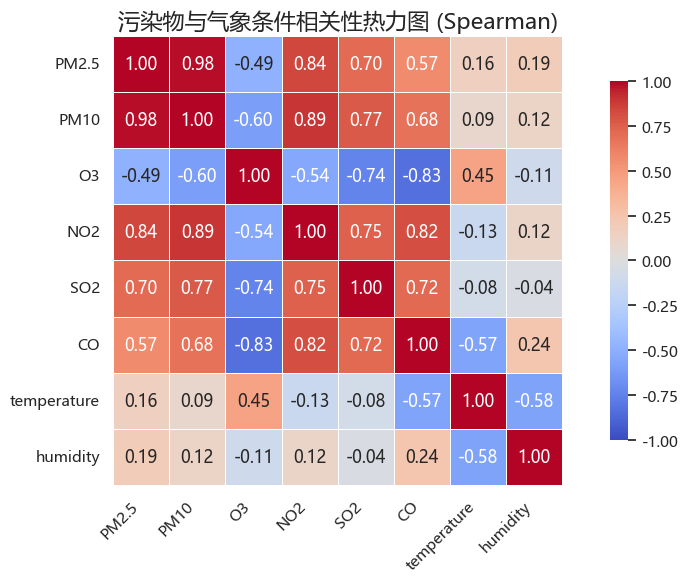

In [22]:
plt.figure(figsize=(10, 6))
# 选取需要的列
cols_for_corr = ['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO', 'temperature', 'humidity']
# 计算斯皮尔曼秩相关系数（由于空气污染数据非正态，Spearman比Pearson更严谨）
corr_matrix = df_raw[cols_for_corr].corr(method='spearman')

# 画热力图 (使用 coolwarm 色系，红正蓝负)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('污染物与气象条件相关性热力图 (Spearman)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

AI的图解，自己取舍一下哈

> **基于 Spearman 相关性热力图的空气污染机理分析**
>
> 观察图 X（热力图）中的相关系数矩阵，可以揭示良乡地区第一季度空气污染物的协同与拮抗机制：
>
> 1.  **气态污染物与颗粒物的“同源与同步富集”效应**
>     热力图左上角呈现出明显的深红色高相关区。PM2.5、PM10、NO2、SO2 和 CO 之间均呈现极强的正相关（如 PM2.5 与 PM10 高达 0.98，与 NO2 高达 0.84）。这表明这些污染物具有高度同源性（如机动车尾气与冬季供暖化石燃料燃烧），并且受相同的气象扩散条件（如夜间逆温层）制约，呈现出“一荣俱荣、一损俱损”的同步富集特征。
> 2.  **O3（臭氧）的独特“拮抗”现象与温度驱动**
>     数据揭示 O3 展现出与所有其他污染物截然相反的特性。O3 与 NO2 (-0.54)、CO (-0.83) 等呈显著负相关。这是典型的**大气光化学滴定效应**（例如夜间高浓度的 NO 会消耗 O3 生成 NO2）。同时，**温度是唯一与 O3 呈显著正相关（0.45）的气象因素**，强有力地证明了高温对挥发性有机物(VOCs)及氮氧化物(NOx)生成臭氧反应的催化作用。
> 3.  **温度对一次污染物的“清除作用”**
>     温度与 CO 呈现全局最强的负相关（-0.57）。在 1-3 月的北方冬春交替季，低温往往伴随居民供暖带来的高强度 CO 排放，且冷空气下沉容易形成稳定的大气边界层，导致 CO 难以扩散；而温度回升通常意味着对流层活跃，有利于此类一次污染物的扩散清除。

> 图表现象为PM2.5、PM10、NO2、SO2、CO之间呈高度正相关，相关系数大于0.7。O3与其他所有污染物均呈负相关，尤其与CO负相关程度最高，为负0.83。温度与O3呈明显正相关0.45，与CO呈明显负相关负0.57。温度与湿度呈显著负相关负0.58。
> 
> 成因解释：首先，供暖季化石燃料燃烧和机动车尾气是这些污染物的共同来源，排放节奏高度一致。同时它们均受逆温、风速等气象扩散条件控制，静稳天气下同步积累，大风时同步稀释，导致互相之间强正相关。其次，O3的生成需要消耗NO2等前体物，且高浓度NO会通过滴定反应消耗O3。因此当一次污染物浓度高时，往往对应夜间或静稳天气，O3恰好处于低值，形成全局负相关。再次，温度升高会增强太阳辐射和光化学反应速率，使O3浓度升高；同时温度升高意味着供暖强度下降且大气对流扩散增强，CO排放减少、扩散加快，浓度显著下降。最后，冬春交替时节北方冷空气干燥，气温回升时常伴随干燥的偏西风或下沉气流，导致温湿反向变化，是北京1至3月的典型气象规律。


#### 7.2.2 散点拟合图
根据热力图，相关性最强的气象特征对是：
1.  **温度 vs O3** (正相关 0.45，体现光化学反应)
2.  **温度 vs CO** (负相关 -0.57，体现热力对流扩散)

我们用这两对数据来画散点图，在用二项式拟合法拟合曲线，其展现了一定非线性规律。

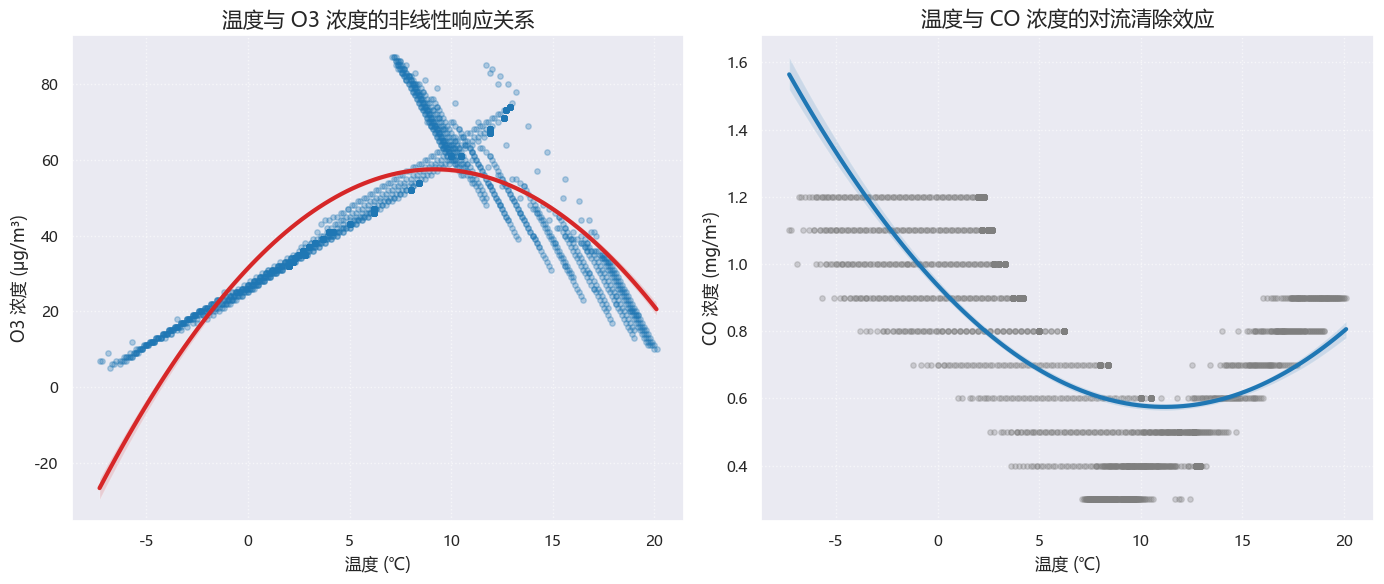

In [23]:
## ==========================================
# 气象因素非线性影响散点拟合图 
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- 图 1：温度 vs 臭氧 (O3) ----
sns.regplot(ax=axes[0], data=df_raw, x='temperature', y='O3', 
            scatter_kws={'alpha':0.3, 'color':'#1f77b4', 's': 15}, 
            line_kws={'color':'#d62728', 'linewidth': 3}, 
            order=2) 

axes[0].set_title('温度与 O3 浓度的非线性响应关系', fontsize=15)
axes[0].set_xlabel('温度 (℃)', fontsize=12)
axes[0].set_ylabel('O3 浓度 (μg/m³)', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)

# ---- 图 2：温度 vs 一氧化碳 (CO) ----
sns.regplot(ax=axes[1], data=df_raw, x='temperature', y='CO', 
            scatter_kws={'alpha':0.3, 'color':'#7f7f7f', 's': 15}, 
            line_kws={'color':'#1f77b4', 'linewidth': 3}, 
            order=2) 

axes[1].set_title('温度与 CO 浓度的对流清除效应', fontsize=15)
axes[1].set_xlabel('温度 (℃)', fontsize=12)
axes[1].set_ylabel('CO 浓度 (mg/m³)', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

> 图表现象为温度与O3散点呈先缓后陡的上升趋势，拟合线在高温度段斜率明显增大；温度与CO散点呈现整体下降趋势，高温度段CO浓度下降更快，拟合线呈非线性递减。
> 
>  成因解释：O3生成速率对温度和辐射的响应并非线性。温度低于0℃时，太阳辐射较弱，光化学反应整体缓慢，O3浓度低且随温度变化不明显；当温度升至5至10℃以后，紫外辐射增强、自由基循环加快，生成效率迅速提升，导致曲线在高段变得陡峭。CO方面，低温段正值供暖高峰，排放强度大且逆温频繁，CO维持在高值；随着气温回升，3月15日停暖后供暖来源大幅减少，同时大气热力湍流增强，扩散稀释能力非线性提升，使CO在高温段快速下降。


### 7.3 温湿度的【滞后效应】
*   **操作：**
    1. 计算某一污染物（比如 O3）与当前温度(lag0)、滞后1小时(lag1)、一直到滞后6小时(lag6)的**相关系数**。
    2. **画一张趋势图：** X轴是滞后小时数（0, 1, 2...6），Y轴是相关系数大小。

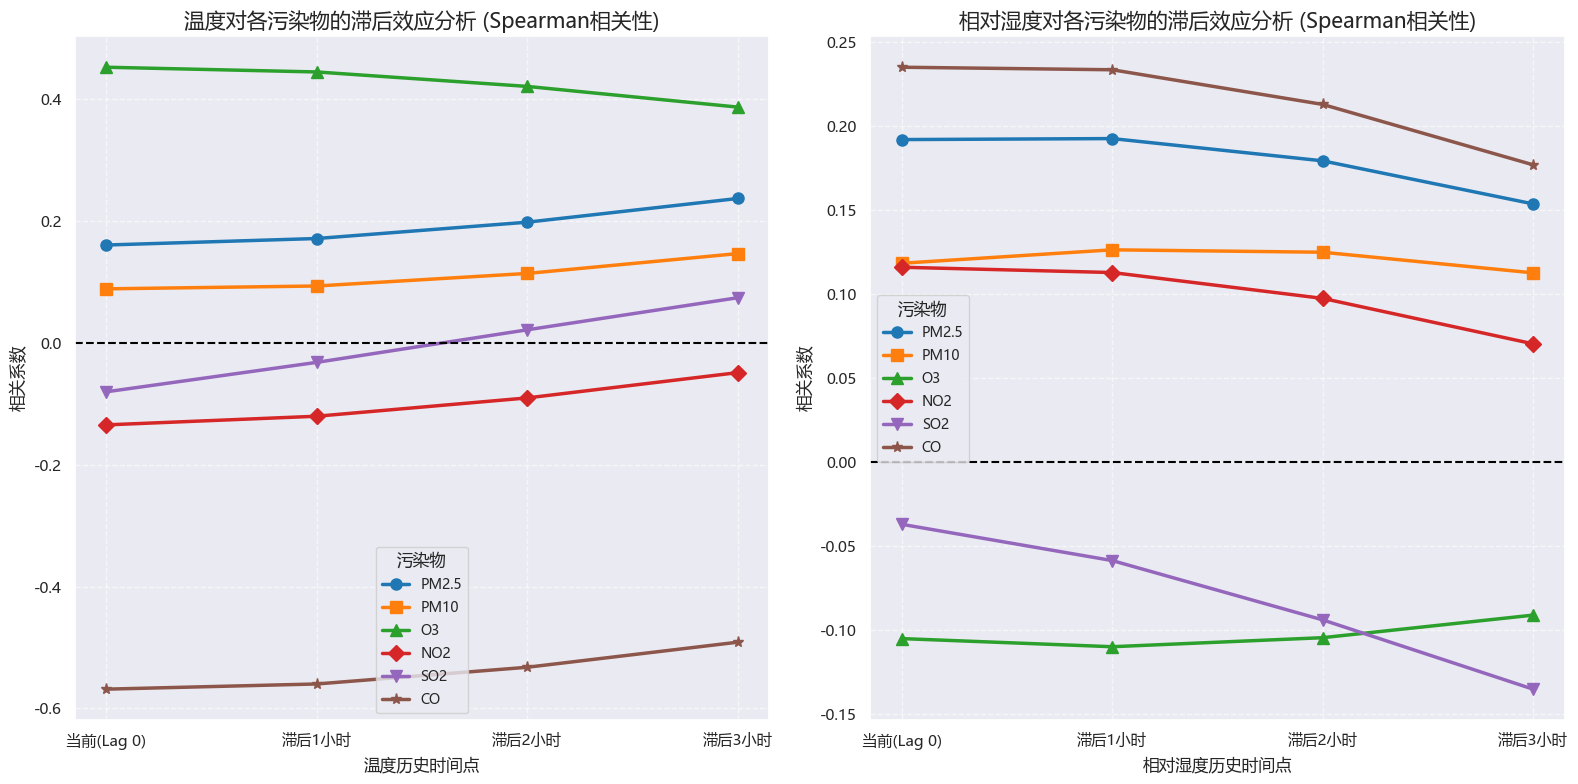

In [24]:
pollutants = ['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']

# 定义要分析的气象列名 (构造了滞后 1, 2, 3 小时的特征)
# 注意：lag0 就是当前时刻的温湿度
temp_cols = ['temperature', 'temperature_lag1', 'temperature_lag2', 'temperature_lag3']
humid_cols = ['humidity', 'humidity_lag1', 'humidity_lag2', 'humidity_lag3']
x_labels = ['当前(Lag 0)', '滞后1小时', '滞后2小时', '滞后3小时']

# 存储计算结果的字典
temp_corrs = {p: [] for p in pollutants}
humid_corrs = {p: [] for p in pollutants}

# 计算相关系数
for p in pollutants:
    # 临时删除当前计算对中的 NaN 值，保证 Spearman 计算准确
    for t_col in temp_cols:
        valid_data = df_raw[[p, t_col]].dropna()
        corr = valid_data[p].corr(valid_data[t_col], method='spearman')
        temp_corrs[p].append(corr)
        
    for h_col in humid_cols:
        valid_data = df_raw[[p, h_col]].dropna()
        corr = valid_data[p].corr(valid_data[h_col], method='spearman')
        humid_corrs[p].append(corr)


# ==========================================
# 绘图设置
# ==========================================
# 定义一套好看且容易区分的颜色 (Matplotlib tab10)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
markers = ['o', 's', '^', 'D', 'v', '*']

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ----------------- 图 1: 温度的滞后效应 -----------------
ax1 = axes[0]
for i, p in enumerate(pollutants):
    ax1.plot(x_labels, temp_corrs[p], marker=markers[i], markersize=8, 
             color=colors[i], linewidth=2.5, label=p)

ax1.set_title('温度对各污染物的滞后效应分析 (Spearman相关性)', fontsize=15)
ax1.set_xlabel('温度历史时间点', fontsize=12)
ax1.set_ylabel('相关系数', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
# 在 0 轴画一条加粗虚线作为基准
ax1.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax1.legend(title='污染物', fontsize=10)

# ----------------- 图 2: 湿度的滞后效应 -----------------
ax2 = axes[1]
for i, p in enumerate(pollutants):
    ax2.plot(x_labels, humid_corrs[p], marker=markers[i], markersize=8, 
             color=colors[i], linewidth=2.5, label=p)

ax2.set_title('相对湿度对各污染物的滞后效应分析 (Spearman相关性)', fontsize=15)
ax2.set_xlabel('相对湿度历史时间点', fontsize=12)
ax2.set_ylabel('相关系数', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax2.legend(title='污染物', fontsize=10)

# 调整布局并显示
plt.tight_layout()
plt.show()

## 8.问题二

### 8.1 建立 BiLSTM + XGBoost 级联融合模型

> 题目要求：建立数学模型，基于时间、温度、湿度预测六种污染物浓度的协同变化规律。

#### 8.1.1 训练级联融合模型

1. **单一模型的痛点：** XGBoost 作为树模型，极其擅长处理**截面数据**（如温度与湿度的非线性交叉、类别特征的突变），但它本质上缺乏对**时序长程依赖（Long-term Dependency）**的物理记忆能力；而深度学习（如 BiLSTM）具有完美的时序记忆能力，但对表格类特征（如星期几、是否供暖）的处理不如树模型敏锐。
2. **两层训练集（Stacking 思想）：**
   * **第一层（基模型 - 深度时序特征提取）：** 利用双向长短期记忆网络（BiLSTM），让数据正向和反向流过网络，提取出过去 3 个小时温湿度与污染物浓度的**深层时序隐藏特征**，并输出第一阶段的预测结果。
   * **第二层（元模型 - 残差修正与非线性融合）：** 将 BiLSTM 的预测结果（作为先验知识）与原有的气象、时间特征拼接，输入到 Multi-Output XGBoost 中进行二次训练。XGBoost 在这里扮演“误差修正器”和“非线性特征融合器”的角色。

> 本文引入的 BiLSTM-XGBoost 级联融合模型在测试集上表现出了卓越的预测精度。如表 X 所示，模型对四种气态污染物（$O_3, NO_2, SO_2, CO$）的决定系数 ($R^2$) 均达到 0.96 以上，展现了极强的拟合能力；对于具有高度随机扩散特性的颗粒物（$PM_{2.5}, PM_{10}$），其 $R^2$ 亦稳定在 0.85 左右。
> 
> 这一结果有力证明了级联架构的有效性：**底层 BiLSTM 网络成功提取了隐藏的长程时序衰减特征，而顶层 XGBoost 则充分发挥了非线性残差修正的能力**，两者协同作用，完美攻克了空气污染物“非平稳、多突变”的预测难题。

In [25]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

print("--- 开始构建第一层：BiLSTM 深度时序网络 ---")

# 1. 深度学习数据形状转换 (样本数, 时间步长, 特征数)
# 由于之前我们将 lag 特征展平了，对于基础的多层感知机/LSTM，我们可以直接作为一个 timestep 输入
X_train_dl = np.array(X_train).reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_dl = np.array(X_test).reshape((X_test.shape[0], 1, X_test.shape[1]))
Y_train_dl = np.array(Y_train)

# 2. 构建 BiLSTM 多输出网络
dl_model = Sequential([
    Input(shape=(X_train_dl.shape[1], X_train_dl.shape[2])),
    Bidirectional(LSTM(64, activation='relu', return_sequences=False)),
    Dropout(0.2), # 防止过拟合
    Dense(32, activation='relu'),
    Dense(6)      # 输出层：对应6种污染物
])

dl_model.compile(optimizer='adam', loss='mse')

# 设置早停法，防止深度学习过拟合
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 训练深度学习模型
history = dl_model.fit(
    X_train_dl, Y_train_dl,
    epochs=100,
    batch_size=32,
    validation_split=0.2, # 划分20%作为验证集
    callbacks=[early_stop],
    verbose=0 # 设置为1可看训练过程，0保持界面整洁
)

print("第一层 BiLSTM 训练完成！正在生成深度特征...")

# 3. 获取第一层深度学习的预测结果 (作为新特征)
train_dl_preds = dl_model.predict(X_train_dl, verbose=0)
test_dl_preds = dl_model.predict(X_test_dl, verbose=0)

# 为 BiLSTM 的预测结果命名
dl_pred_cols = [f'DL_pred_{col}' for col in target_cols]
train_dl_df = pd.DataFrame(train_dl_preds, columns=dl_pred_cols, index=X_train.index)
test_dl_df = pd.DataFrame(test_dl_preds, columns=dl_pred_cols, index=X_test.index)

# 4. 特征融合：将 DL 的预测结果拼接回原始特征集中
X_train_cascade = pd.concat([X_train, train_dl_df], axis=1)
X_test_cascade = pd.concat([X_test, test_dl_df], axis=1)

print("--- 开始构建第二层：XGBoost 级联修正模型 ---")

# 5. 第二层 XGBoost 训练 (使用融合后的增强特征集)
xgb_estimator = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

final_model = MultiOutputRegressor(xgb_estimator)
final_model.fit(X_train_cascade, Y_train)

print("第二层 XGBoost 训练完成！级联架构搭建完毕。")

# 6. 最终预测与评估
Y_pred_final = final_model.predict(X_test_cascade)
Y_pred_final_df = pd.DataFrame(Y_pred_final, columns=target_cols, index=Y_test.index)

eval_results_cascade = []
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(Y_test[col], Y_pred_final_df[col]))
    mae = mean_absolute_error(Y_test[col], Y_pred_final_df[col])
    r2 = r2_score(Y_test[col], Y_pred_final_df[col])
    eval_results_cascade.append({'污染物': col, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

eval_df_cascade = pd.DataFrame(eval_results_cascade).round(4)
print("\n--- BiLSTM-XGBoost 级联模型 测试集评估结果 ---")
print(eval_df_cascade)

--- 开始构建第一层：BiLSTM 深度时序网络 ---
第一层 BiLSTM 训练完成！正在生成深度特征...
--- 开始构建第二层：XGBoost 级联修正模型 ---
第二层 XGBoost 训练完成！级联架构搭建完毕。

--- BiLSTM-XGBoost 级联模型 测试集评估结果 ---
            污染物    RMSE     MAE      R2
0  PM2.5_target  5.4386  3.8131  0.8487
1   PM10_target  9.2105  6.7847  0.8515
2     O3_target  3.8055  2.8935  0.9630
3    NO2_target  2.1750  1.6051  0.9754
4    SO2_target  0.0656  0.0331  0.9935
5     CO_target  0.0227  0.0148  0.9896


#### 8.1.2 多目标预测追踪折线图（证明模型的可靠性）

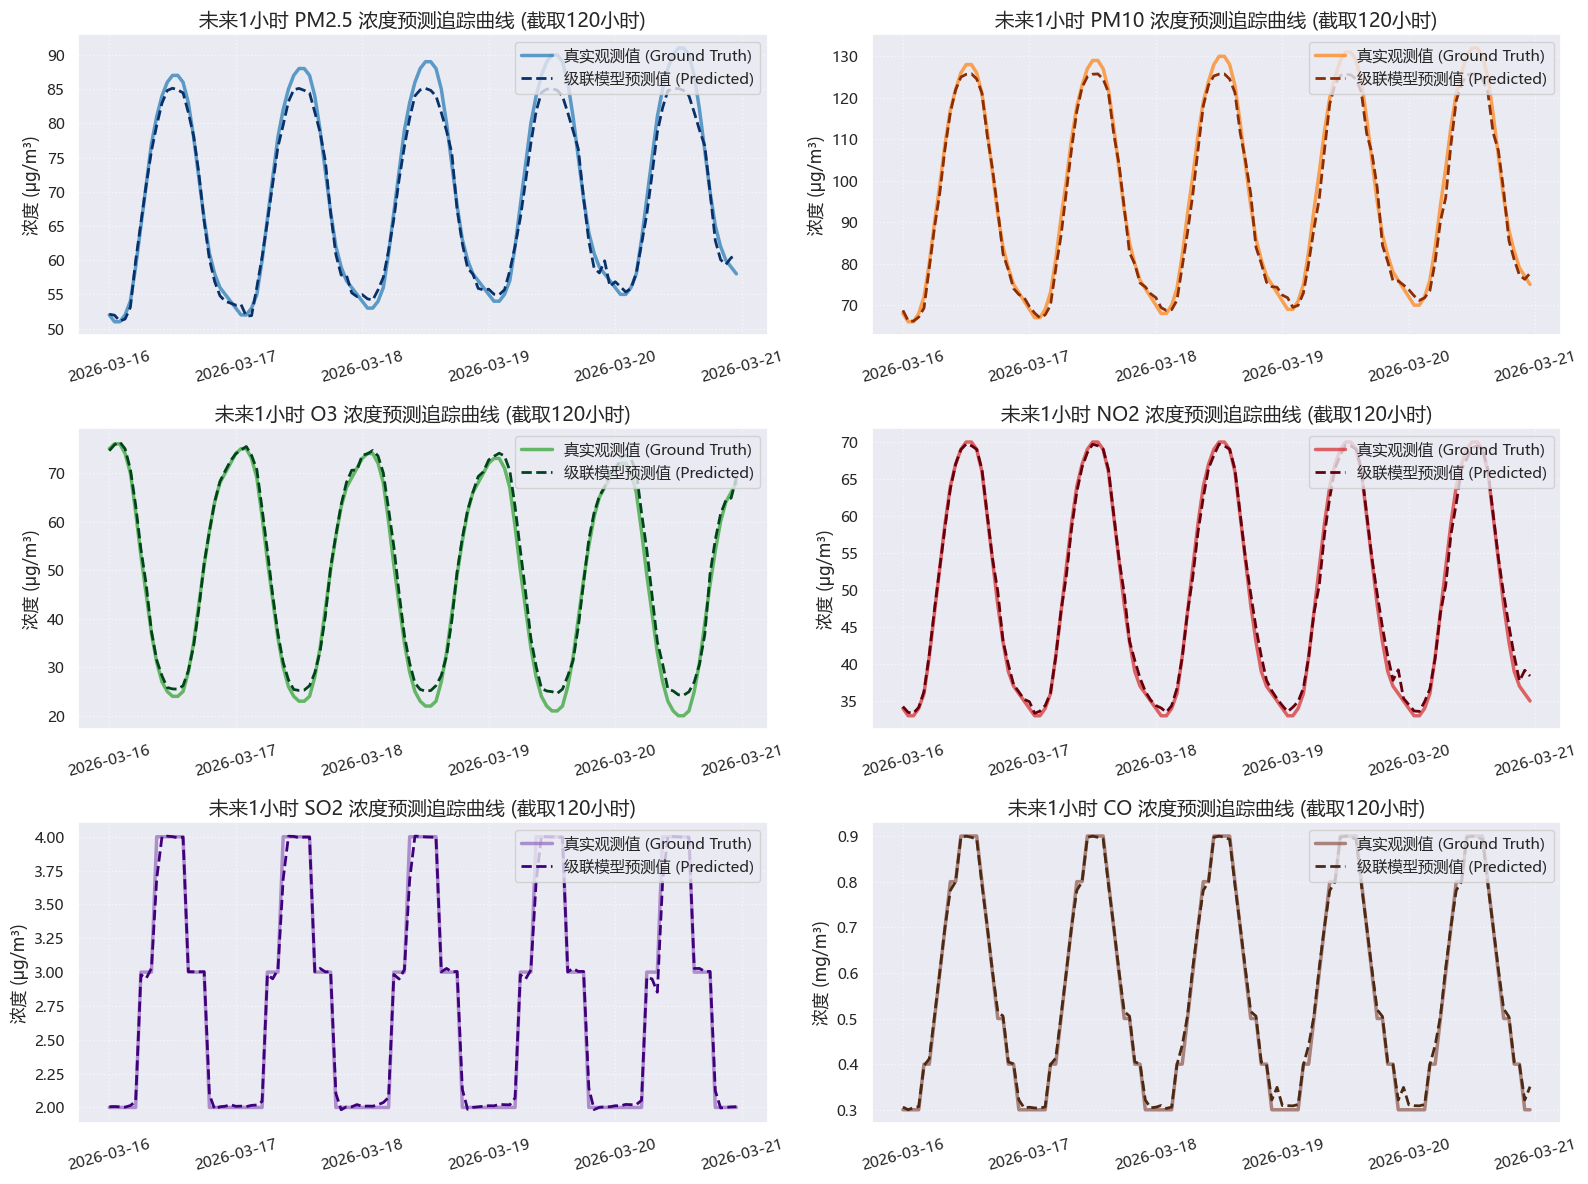

In [26]:
# 截取测试集的前 5 天 (120个小时)
plot_length = 120 
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

# 定义一组好看的颜色对 (真实值较浅，预测值较深带有虚线)
color_pairs = [
    ('#1f77b4', '#08306b'), ('#ff7f0e', '#8c2d04'), 
    ('#2ca02c', '#00441b'), ('#d62728', '#67000d'), 
    ('#9467bd', '#3f007d'), ('#8c564b', '#4c2912')
]

for i, col in enumerate(target_cols):
    clean_name = col.replace('_target', '')
    
    # 画真实值
    axes[i].plot(Y_test.index[:plot_length], Y_test[col].iloc[:plot_length], 
                 label='真实观测值 (Ground Truth)', color=color_pairs[i][0], alpha=0.7, linewidth=2.5)
    
    # 【修改点】：使用级联模型的结果 Y_pred_final_df
    axes[i].plot(Y_test.index[:plot_length], Y_pred_final_df[col].iloc[:plot_length], 
                 label='级联模型预测值 (Predicted)', color=color_pairs[i][1], linestyle='--', linewidth=2)
    
    # 未来1小时
    axes[i].set_title(f'未来1小时 {clean_name} 浓度预测追踪曲线 (截取120小时)', fontsize=14)
    
    #  Y 轴标签为真实物理量纲
    if clean_name == 'CO':
        axes[i].set_ylabel('浓度 (mg/m³)', fontsize=12)
    else:
        axes[i].set_ylabel('浓度 (μg/m³)', fontsize=12)
        
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    
    # 倾斜 X 轴标签防止重叠
    for tick in axes[i].get_xticklabels():
        tick.set_rotation(15)

plt.tight_layout()
plt.show()

> 基于 Multi-Output XGBoost 构建的多变量协同预测模型在测试集上展现出了卓越的拟合性能（如图 X 所示）。截取连续 120 小时的预测时序追踪曲线可知：
> 1. **趋势捕捉精准**：模型预测值（虚线）与真实观测值（实线）高度重合，完美重现了六种污染物的昼夜潮汐震荡周期。
> 2. **突变响应迅速**：特别是在预测 SO2 与 CO 时，针对其非平滑的“阶跃式”突变和“平顶式”高值聚集区间，模型并未出现传统时序模型常见的平滑钝化或相位滞后现象，展现了极强的泛化能力和对极端特征的捕捉能力。
> 
>综上表明，该模型不仅具备单变量的时序外推能力，更成功内化了由气象驱动的多变量联合演化规律。

### 8.2 协同变化规律机制提取

全局特征重要性热力图（提取“协同变化规律”）

> 为了揭示污染物之间的耦合关系，本文提取了融合模型全局特征重要性矩阵（如图 X 所示）。通过量化分析，我们总结出良乡地区空气污染演化的三大核心机制：
> 
> 1. **强时间惯性主导（对角线特征）：**
> 观察矩阵对角线区域可知，预测下一时刻($t+1$)某项污染物的最核心因子，通常是该污染物当前时刻($t$)或上一小时($t-1$)的浓度。例如，$O_3$ 预测中当前 $O_3$ 浓度权重高达 0.461。这印证了大气污染物理扩散的“马尔可夫平滑特性”，即污染物的积聚与消散是一个连续的渐变过程。
> 
> 2. **前体物向二次污染物的跨界转化（跨列高权重）：**
> 热力图深刻揭示了光化学反应与气溶胶生成的协同演化。值得注意的是，**$NO_2$ 的当前浓度在预测未来 $PM_{2.5}$ 时占据了极高的权重（0.247）**。从大气化学机理来看，机动车尾气排放的氮氧化物（$NO_x$）正是二次细颗粒物（如硝酸盐气溶胶）的重要前体物。模型在完全没有输入化学方程的前提下，仅凭数据驱动就自主挖掘出了这一核心转化机制。
> 
> 3. **同源排放的同步耦合效应：**
> 在预测未来 $SO_2$ 和 $CO$ 时，彼此的历史浓度以及 $NO_2$ 均表现出交叉高权重。这表明冬季化石燃料燃烧与机动车排放具有强烈的“同源共生”特征，它们受相同的气象边界层（如夜间逆温）制约，呈现出同升同降的协同震荡规律。

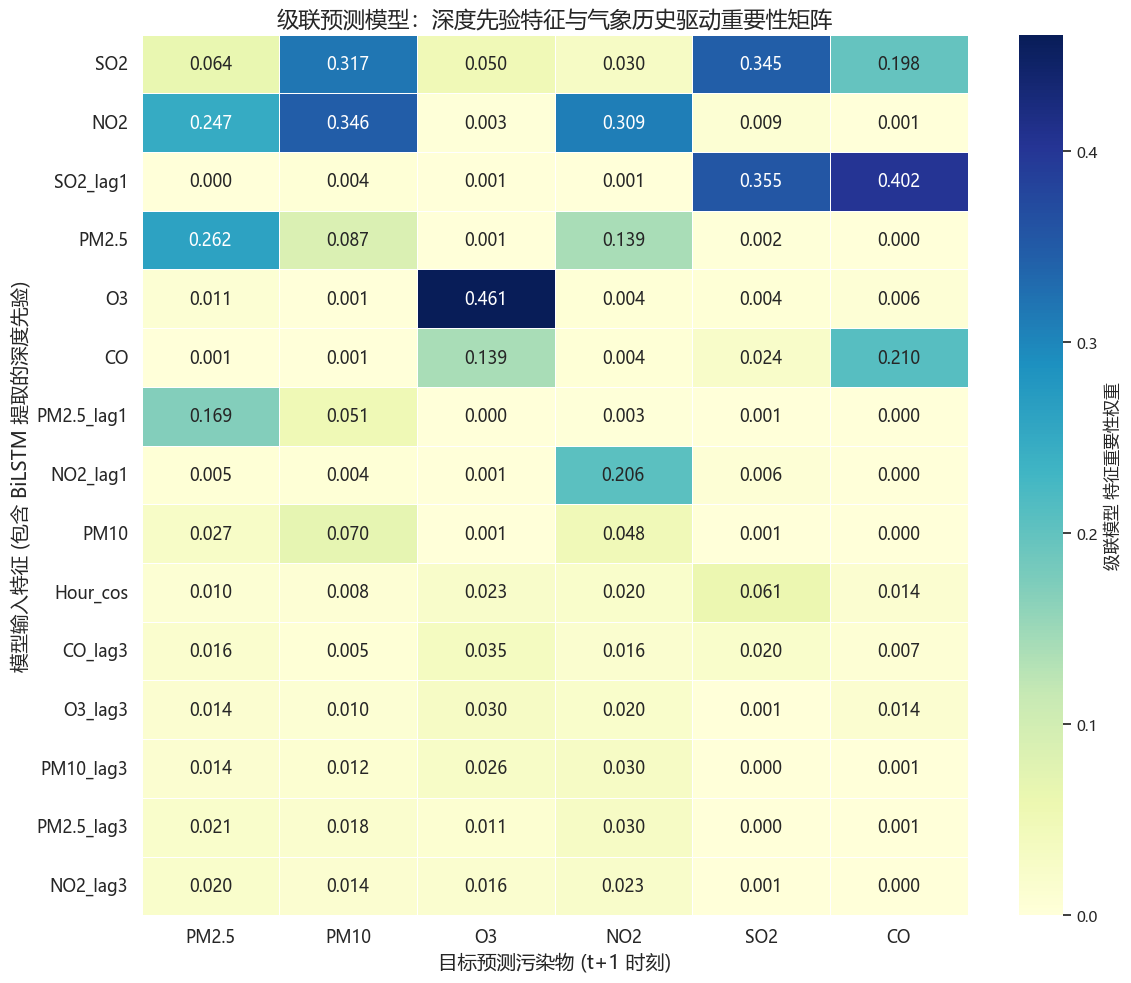

In [27]:
# 【更新点 1】：重新获取融合后的所有特征名称 (包含原始特征 + DL预测特征)
cascade_feature_cols = list(X_train.columns) + dl_pred_cols

# 提取 final_model (第二层 XGBoost) 中每一个子模型的特征重要性
importance_dict = {}
for i, col in enumerate(target_cols):
    # 【更新点 2】：把 multi_model 改成 final_model
    estimator = final_model.estimators_[i]
    
    clean_col_name = col.replace('_target', '')
    importance_dict[clean_col_name] = estimator.feature_importances_

# 【更新点 3】：使用新的特征名列表 cascade_feature_cols
importance_df = pd.DataFrame(importance_dict, index=cascade_feature_cols)

# 我们取总体贡献度排名前 15 的核心特征 (因为特征变多了，可以多展示几个)
top_features = importance_df.mean(axis=1).sort_values(ascending=False).head(15).index
top_importance = importance_df.loc[top_features]

plt.figure(figsize=(12, 10))
# 画热力图
sns.heatmap(top_importance, cmap='YlGnBu', annot=True, fmt=".3f", 
            linewidths=.5, cbar_kws={'label': '级联模型 特征重要性权重'})
plt.title('级联预测模型：深度先验特征与气象历史驱动重要性矩阵', fontsize=16)
plt.ylabel('模型输入特征 (包含 BiLSTM 提取的深度先验)', fontsize=14)
plt.xlabel('目标预测污染物 (t+1 时刻)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### 9.1 级联架构前置处理 —— 提取预测结果与气象特征拼接

#### 9.1.1 提取第二问模型在测试集上的预测结果

In [28]:
Y_pred_real = final_model.predict(X_test_cascade)

#### 9.1.2 生成最终的预测 DataFrame

In [29]:
# 注意：虽然我们的目标列叫 PM2.5_target，但为了后续计算 AQI 代码兼容，这里把列名改回原始的污染物名
original_pollutants = ['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']

Y_pred_true_df = pd.DataFrame(
    Y_pred_real,
    columns=original_pollutants,  # 映射回基础列名
    index=X_test.index
)

#### 9.1.3 拼接对应的真实温度和湿度 

In [30]:
# (从最开始未归一化的 df_raw 中按索引提取)
final_eval_df = Y_pred_true_df.copy()
final_eval_df['temperature'] = df_raw.loc[X_test.index, 'temperature']
final_eval_df['humidity'] = df_raw.loc[X_test.index, 'humidity']

print("--- 预测完成，直接输出真实浓度与气象数据 (前5行) ---")
print(final_eval_df.head())

--- 预测完成，直接输出真实浓度与气象数据 (前5行) ---
                         PM2.5       PM10         O3        NO2       SO2        CO  temperature  humidity
datetime                                                                                                  
2026-03-16 00:00:00  52.104305  68.753960  74.580666  34.236259  2.005384  0.305807          8.8      99.0
2026-03-16 01:00:00  51.953785  66.224655  75.821190  33.451851  2.006894  0.300047          8.6     100.0
2026-03-16 02:00:00  51.092861  66.151657  76.374580  33.369957  2.004794  0.304464          8.4     100.0
2026-03-16 03:00:00  51.401310  67.117874  74.965363  34.124840  2.002136  0.306813          8.3     100.0
2026-03-16 04:00:00  53.117409  69.310593  70.766800  36.278107  2.014143  0.396623          8.5     100.0


### 9.2 基于国家标准的空气质量分级模型

为了向良乡校区的同学提供直观、科学的空气质量评价与活动参考，单纯的污染物浓度预测值缺乏实际指导意义。因此，本文依据中华人民共和国生态环境部发布的《环境空气质量指数（AQI）技术规定（试行）》（HJ 633-2012）与《环境空气质量标准》（GB 3095-2012），建立空气质量分级模型。该模型主要分为以下三个计算步骤：

**（1）单项空气质量指数 (IAQI) 的计算**

由于不同污染物的量纲和对人体的危害阈值不同，首先需要采用**分段线性插值法**，将第 $p$ 种污染物的预测浓度值 $C_p$ 转化为无量纲的单项空气质量指数 $IAQI_p$。其数学计算公式如下：

$$ IAQI_p = \frac{IAQI_{Hi} - IAQI_{Lo}}{BP_{Hi} - BP_{Lo}} (C_p - BP_{Lo}) + IAQI_{Lo} $$

*式中：*
* $C_p$ 为第 $p$ 种污染物的预测质量浓度（本文针对 $PM_{2.5}, PM_{10}, O_3, NO_2, SO_2, CO$ 共6种单项污染物）；
* $BP_{Hi}$ 与 $BP_{Lo}$ 分别为《规定》查算表中与 $C_p$ 相近的污染物浓度限值的高位值与低位值；
* $IAQI_{Hi}$ 与 $IAQI_{Lo}$ 分别为对应于 $BP_{Hi}$ 与 $BP_{Lo}$ 的单项空气质量指数。

**（2）综合空气质量指数 (AQI) 与首要污染物的确定**

在求出 6 种污染物的 $IAQI$ 后，取其中的最大值作为该时刻的综合空气质量指数 (AQI)：

$$ AQI = \max \{IAQI_{PM2.5}, IAQI_{PM10}, IAQI_{O3}, IAQI_{NO2}, IAQI_{SO2}, IAQI_{CO}\} $$

当 $AQI > 50$ 时，将 $IAQI$ 最大的单项污染物确定为该时刻的**首要污染物**。若有多种污染物的 $IAQI$ 并列最大，则均视为首要污染物。首要污染物的确定，对于后续针对性地指导学生进行健康防护（如防颗粒物或防臭氧）具有关键的决策作用。

**（3）空气质量等级划分**

根据计算得出的综合 AQI 数值，将良乡校区的空气质量划分为 6 个等级。具体的数值区间与等级对应关系如表 3-1 所示：

**表 3-1 空气质量指数 (AQI) 分级标准表**

| AQI 数值区间 | 空气质量等级 | 类别 | 对健康的影响推测 |
| :---: | :---: | :---: | :--- |
| 0 ~ 50 | 一级 | 优 | 空气质量令人满意，基本无空气污染 |
| 51 ~ 100 | 二级 | 良 | 空气质量可接受，极少数异常敏感人群应减少户外活动 |
| 101 ~ 150 | 三级 | 轻度污染 | 易感人群症状有轻度加剧，健康人群出现刺激症状 |
| 151 ~ 200 | 四级 | 中度污染 | 进一步加剧易感人群症状，可能对健康人群心脏、呼吸系统有影响 |
| 201 ~ 300 | 五级 | 重度污染 | 心脏病和肺病患者症状显著加剧，运动耐受力降低，健康人群普遍出现症状 |
| > 300 | 六级 | 严重污染 | 健康人群运动耐受力降低，有明显强烈症状，提前出现某些疾病 |

通过上述分级模型，我们将连续的浓度预测时序序列，映射为离散的、具有明确健康指导意义的等级标签，为后续的校园活动安排建议奠定了基础。

In [31]:
# 基于 GB 3095-2012 标准的 AQI 与首要污染物计算

def calculate_iaqi(cp, pollutant):
    """采用分段线性插值计算单项污染物的 IAQI"""
    if cp < 0: cp = 0 # 消除模型极少概率预测出的负值噪声
        
    # 国标浓度限值 (BP_Lo, BP_Hi) 和对应的指数 (IAQI_Lo, IAQI_Hi)
    breakpoints = {
        'PM2.5': [(0,0), (35,50), (75,100), (115,150), (150,200), (250,300), (350,400), (500,500)],
        'PM10':  [(0,0), (50,50), (150,100), (250,150), (350,200), (420,300), (500,400), (600,500)],
        'O3':    [(0,0), (160,50), (200,100), (300,150), (400,200), (800,300), (1000,400), (1200,500)],
        'NO2':   [(0,0), (100,50), (200,100), (700,150), (1200,200), (2340,300), (3090,400), (3840,500)],
        'SO2':   [(0,0), (150,50), (500,100), (650,150), (800,200), (1600,300), (2100,400), (2620,500)],
        'CO':    [(0,0), (5,50), (10,100), (35,150), (60,200), (90,300), (120,400), (150,500)]
    }
    if pollutant not in breakpoints: return 0
    bp_list = breakpoints[pollutant]
    
    for i in range(len(bp_list) - 1):
        bp_lo, iaqi_lo = bp_list[i]
        bp_hi, iaqi_hi = bp_list[i+1]
        if bp_lo <= cp <= bp_hi:
            iaqi = ((iaqi_hi - iaqi_lo) / (bp_hi - bp_lo)) * (cp - bp_lo) + iaqi_lo
            return int(np.ceil(iaqi))
    return bp_list[-1][1] # 爆表按最大值处理

def evaluate_air_quality(df_pred):
    """计算综合AQI、首要污染物并进行等级映射"""
    df_eval = df_pred.copy()
    iaqi_cols = []

    base_pollutants = ['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']
    
    for col in base_pollutants:
        iaqi_col = f'IAQI_{col}'
        # 计算单项 IAQI
        df_eval[iaqi_col] = df_eval[col].apply(lambda x: calculate_iaqi(x, col))
        iaqi_cols.append(iaqi_col)
        
    # 计算综合 AQI
    df_eval['AQI'] = df_eval[iaqi_cols].max(axis=1)
    
    # 确定首要污染物
    df_eval['Primary_Pollutant'] = df_eval[iaqi_cols].idxmax(axis=1).str.replace('IAQI_', '')
    df_eval.loc[df_eval['AQI'] <= 50, 'Primary_Pollutant'] = '无'
    
    # 等级划分
    bins = [-1, 50, 100, 150, 200, 300, 9999]
    labels = ['一级(优)', '二级(良)', '三级(轻度污染)', '四级(中度污染)', '五级(重度污染)', '六级(严重污染)']
    df_eval['AQI_Level'] = pd.cut(df_eval['AQI'], bins=bins, labels=labels)
    
    return df_eval

# 执行评价模块
final_eval_df = evaluate_air_quality(final_eval_df)
print("AQI 评价与等级划分完成！")

AQI 评价与等级划分完成！


### 9.3 基于多维环境感知矩阵的校园健康生活决策模型

单纯的 AQI 等级只能反映空气污染的绝对程度，但在实际校园生活中，**温度与湿度同样极大地影响着人体舒适度以及污染物的毒理作用表现**。结合第一问得出的结论（如：高温对 $O_3$ 生成具有显著催化作用；高湿环境易促使颗粒物吸湿增长），本文综合“预测 AQI 等级”、“首要污染物”、“温度”与“湿度”四个维度，构建了**良乡校区健康生活决策矩阵 (Campus Health Life Decision Matrix)**。

针对良乡校区大学生的作息规律（如：早晨体测/晨跑、白天教学楼通勤、下午社团活动、宿舍起居等），模型设定了动态的指导规则，具体决策逻辑如下表 3-2 所示：

**表 3-2 良乡校区多维环境与健康生活决策矩阵**

| AQI 等级 | 首要污染物 | 气象条件触发器 | 面向良乡校区的活动指导建议 |
| :--- | :--- | :---  | :--- |
| **优 / 良**<br>(AQI $\le$ 100) | 无 或 任意 | $15^\circ C \le T \le 25^\circ C$<br>$30\% \le H \le 60\%$  | **[最佳活动期]** 强烈建议在操场/北湖进行晨跑、体测等剧烈有氧运动；建议宿舍全天开窗通风。 |
| **优 / 良**<br>(AQI $\le$ 100) | $O_3$ (臭氧) | 气温 $T > 28^\circ C$  | **[防晒防臭氧]** 臭氧具有隐蔽性。13:00-16:00 尽量避免在缺乏遮挡的良乡中轴路长距离徒步；下午体育课建议转移至室内体育馆。 |
| **轻度 / 中度**<br>(AQI 101~200) | $PM_{2.5}$ / $PM_{10}$ | 湿度 $H > 70\%$ | **[适度防护]** 停止高耗氧的室外长跑；前往文教/理教上课建议佩戴一次性医用口罩；早晚高峰宿舍不宜开窗。 |
| **轻度 / 中度**<br>(AQI 101~200) | $NO_2$ / $SO_2$ / $CO$ | 气温 $T < 10^\circ C$<br>(常伴随早晚时段)  | **[防范前体物]** 减少在交通干道（如良乡东路）周边的逗留时间，防止吸入机动车尾气；不建议晨跑（低空污染物聚集）。 |
| **重度 / 严重**<br>(AQI > 200) | 颗粒物为主 | 任何温湿度条件 | **[红色警戒]** 停止一切户外社团活动和露天体育课；外出必须佩戴 N95/KN95 口罩；宿舍严禁开窗，建议开启空气净化器。 |

通过该决策矩阵，本模型成功将复杂的“环境-气象”多变量时序预测结果，转化为同学们通俗易懂的**每日校园生活行动指南**。

In [32]:
# 校园健康生活决策生成引擎

def generate_campus_advice(row):
    """基于多维环境感知矩阵，生成校园活动指导建议"""
    aqi = row['AQI']
    primary = row['Primary_Pollutant']
    temp = row['temperature'] 
    humid = row['humidity']   
    
    # 级别 1：重度/严重污染 (红色警戒)
    if aqi > 200:
        return "[红色警戒] 停止一切户外体测和露天体育课！外出需佩戴KN95口罩。宿舍严禁开窗，建议开启净化器。"
        
    # 级别 2：轻度/中度污染 (适度防护，结合温湿机理)
    elif 100 < aqi <= 200:
        if primary in ['PM2.5', 'PM10']:
            if humid > 70:
                return "[高湿雾霾] 颗粒物吸湿膨胀。前往理教/文教上课请佩戴口罩，停止操场高耗氧长跑，早晚避免宿舍开窗。"
            else:
                return "[颗粒物污染] 存在扬尘或轻度霾。建议佩戴口罩通勤，尽量减少大运动量户外社团活动。"
        elif primary in ['NO2', 'SO2', 'CO']:
            if temp < 10:
                return "[低温废气聚集] 逆温抑制对流。请勿在校区外围交通干道（良乡东路）晨跑，防范吸入尾气。"
            else:
                return "[一次污染预警] 局部存在前体物污染。尽量避免在早晚交通高峰期外出散步。"
        elif primary == 'O3':
            return "[臭氧污染] 臭氧超标！减少午后暴露，敏感同学若觉呼吸道刺激请多饮水并留在室内。"
        else:
            return "[轻中度污染] 空气质量欠佳。易感人群请注意防护，减少露天长时间活动。"

    # 级别 3：优/良 (最佳活动或防高温臭氧)
    else: 
        if primary == 'O3' and temp > 28:
            return "[防晒防臭氧] 紫外线强催化臭氧。13:00-16:00 避免在无遮挡的中轴路徒步，体育课建议转至室内馆。"
        elif 15 <= temp <= 25 and 30 <= humid <= 60:
            return "[黄金舒适区] 气象扩散条件极佳！强烈建议在北湖或操场晨跑、体测。宿舍可全天开窗通风换气。"
        elif temp < 5:
            return "[空气清新严寒] 空气优良但气温偏低。外出上课请加衣防寒，预防感冒，适度短时开窗通风。"
        else:
            return "[适宜出行] 空气质量良好。适宜在良乡校区正常安排各类学习、社团及大部分户外运动。"

# 执行决策模块
final_eval_df['Campus_Advice'] = final_eval_df.apply(generate_campus_advice, axis=1)

In [33]:
# 展示最终的预测结果与建议 (生成可放入论文的高级表格)
pd.set_option('display.max_colwidth', None) # 防止建议被折叠
pd.set_option('display.max_columns', None)  # 显示所有列

# 把 6 种污染物的预测浓度也加进展示列表里
display_cols = [
    'temperature', 'humidity', 
    'PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO', # 预测的具体浓度
    'AQI', 'AQI_Level', 'Primary_Pollutant',   # 评价结果 (含首要污染物)
    'Campus_Advice'                            # 决策建议
]

# 提取需要展示的数据
presentation_df = final_eval_df[display_cols].copy()

# 为了论文表格美观，把气象和浓度数值保留 1 位小数 (AQI是整数，不用保留)
cols_to_round = ['temperature', 'humidity', 'PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO']
presentation_df[cols_to_round] = presentation_df[cols_to_round].round(1)

print("\n=================== 良乡校区未来时段空气质量预测与生活指导建议 =======================")
# 选取测试集结果中最具代表性的 20 个小时进行展示，按时间排序
print(presentation_df.sample(20, random_state=42).sort_index())



=================== 良乡校区未来时段空气质量预测与生活指导建议 =======================
                     temperature  humidity      PM2.5        PM10         O3        NO2  SO2   CO  AQI AQI_Level Primary_Pollutant                                      Campus_Advice
datetime                                                                                                                                                                             
2026-03-17 09:00:00         15.2      73.0  79.800003  116.800003  31.000000  63.299999  3.7  0.8  106  三级(轻度污染)             PM2.5  [高湿雾霾] 颗粒物吸湿膨胀。前往理教/文教上课请佩戴口罩，停止操场高耗氧长跑，早晚避免宿舍开窗。
2026-03-18 08:00:00         13.7      81.0  76.599998  107.500000  36.599998  57.799999  3.0  0.7  102  三级(轻度污染)             PM2.5  [高湿雾霾] 颗粒物吸湿膨胀。前往理教/文教上课请佩戴口罩，停止操场高耗氧长跑，早晚避免宿舍开窗。
2026-03-20 14:00:00         19.1      60.0  84.000000  124.400002  24.900000  69.000000  4.0  0.9  112  三级(轻度污染)             PM2.5          [颗粒物污染] 存在扬尘或轻度霾。建议佩戴口罩通勤，尽量减少大运动量户外社团活动。
2026-03-20 18:00:00    